Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import umap

Settings

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

Load data

In [3]:
features = pd.read_csv("../data/civ5_features.csv")

leader_names = features["leader_name"]
X = features.drop(columns=["leader_name"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset: {X.shape[0]} leaders x {X.shape[1]} features")

Dataset: 43 leaders x 19 features


K-means: number of clusters selection

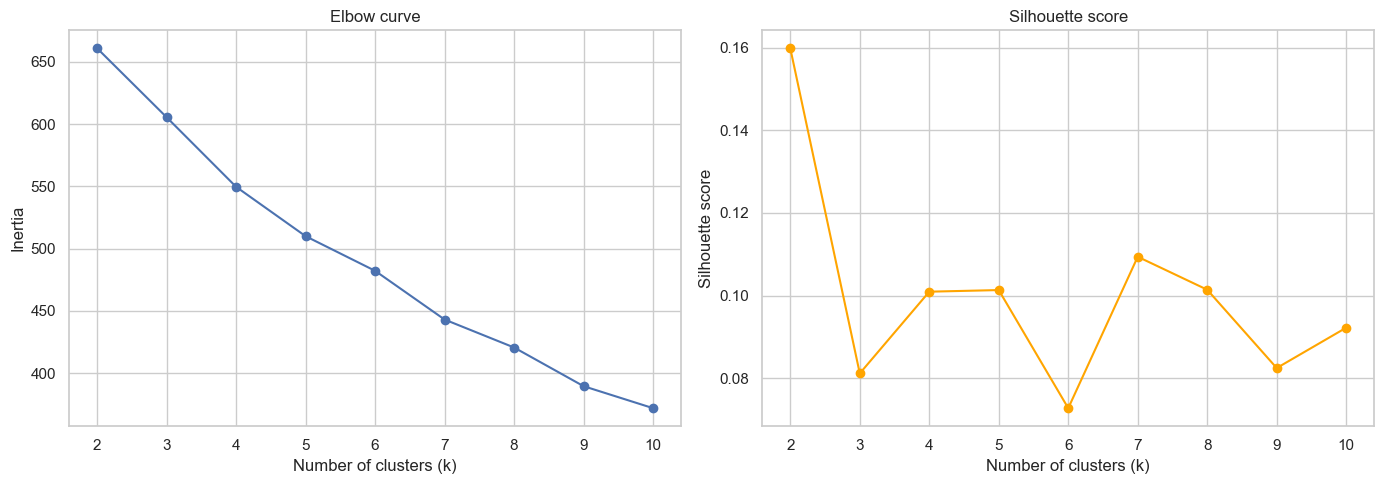

In [4]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow curve")

axes[1].plot(k_range, silhouettes, marker="o", color="orange")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score")

plt.tight_layout()
plt.savefig("../figures/kmeans_selection.png", dpi=150, bbox_inches="tight")
plt.show()

K-means: fit k=5

In [5]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
features["cluster"] = kmeans.fit_predict(X_scaled)

for cluster_id in sorted(features["cluster"].unique()):
    leaders = features[features["cluster"] == cluster_id]["leader_name"].tolist()
    print(f"\nCluster {cluster_id} ({len(leaders)} leaders):")
    print(", ".join(sorted(leaders)))


Cluster 0 (9 leaders):
Casimir, Elizabeth, Gustavus, Hiawatha, Kamehameha, Maria, MariaI, Washington, William

Cluster 1 (7 leaders):
Alexander, Augustus, Bismark, Catherine, Napoleon, OdaNobunaga, Suleiman

Cluster 2 (10 leaders):
Ashurbanipal, Askia, Attila, Boudicca, Dido, GenghisKhan, Harald, Isabella, Montezuma, Shaka

Cluster 3 (6 leaders):
AhmadalMansur, Gandhi, Pedro, Pocatello, Ramkhamhaeng, Selassie

Cluster 4 (11 leaders):
Darius, EnricoDandolo, GajahMada, HarunAlRashid, Nebuchadnezzar, Pacal, Pachacuti, Ramesses, Sejong, Theodora, WuZetian


Cluster profiles

In [6]:
cluster_profiles = (features
                    .drop(columns=["leader_name"])
                    .groupby("cluster")
                    .mean()
                    .round(2))
print(cluster_profiles.T)

cluster                     0     1     2     3     4
WarmongerHate            6.33  4.29  3.80  6.50  5.09
WonderCompetitiveness    4.44  6.00  4.30  4.50  6.09
VictoryCompetitiveness   4.22  6.86  6.10  4.00  5.00
Loyalty                  6.22  4.43  5.80  6.17  4.82
MinorCivCompetitiveness  5.78  6.29  4.20  4.33  4.82
warrior                  4.67  6.09  6.74  4.03  4.40
friendliness             5.72  4.71  3.95  6.17  5.68
deceptiveness            4.33  6.29  5.00  4.33  5.64
city_state_stance       -2.33 -0.93  2.40 -2.92 -1.00
minor_ignore             4.33  4.43  4.40  4.50  4.36
naval                    5.56  5.03  5.46  3.87  4.80
defense                  6.00  5.14  4.45  6.58  6.32
science                  5.50  6.86  4.95  5.25  6.27
EXPANSION                6.56  7.86  7.00  5.00  5.00
GROWTH                   3.67  4.43  4.70  7.33  5.91
WONDER                   4.78  5.00  4.00  5.00  6.64
CULTURE                  5.78  6.14  5.10  7.00  5.82
RELIGION                 5.3

Save cluster assignments

In [7]:
features[["leader_name", "cluster"]].to_csv("../data/civ5_clusters.csv", index=False)
print("Cluster assignments saved!")

Cluster assignments saved!


Constants

In [8]:
CLUSTER_LABELS = {
    0: "Diplomatic builders",
    1: "Scientific conquerors",
    2: "Aggressive warmongers",
    3: "Peaceful culturalists",
    4: "Wonder seekers"
}
CLUSTER_COLORS = ["#2ecc71", "#e74c3c", "#e67e22", "#3498db", "#9b59b6"]

PCA: fit and variance explained

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Total: {pca.explained_variance_ratio_.sum():.1%}")

Variance explained: PC1=26.4%, PC2=12.8%
Total: 39.2%


PCA: loadings analysis

In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=["PC1", "PC2"]
)

print("PC1 — top contributions:")
print(loadings["PC1"].sort_values(ascending=False).round(3))

print("\nPC2 — signed values (sorted):")
print(loadings["PC2"].sort_values(ascending=False).round(3))

PC1 — top contributions:
warrior                    0.386
VictoryCompetitiveness     0.311
city_state_stance          0.304
EXPANSION                  0.299
naval                      0.135
deceptiveness              0.051
MinorCivCompetitiveness   -0.013
Loyalty                   -0.047
minor_ignore              -0.064
WonderCompetitiveness     -0.074
DIPLOMACY                 -0.100
science                   -0.121
GROWTH                    -0.218
WONDER                    -0.220
RELIGION                  -0.223
CULTURE                   -0.235
WarmongerHate             -0.305
defense                   -0.332
friendliness              -0.333
Name: PC1, dtype: float64

PC2 — signed values (sorted):
Loyalty                    0.492
WarmongerHate              0.268
DIPLOMACY                  0.219
naval                      0.148
EXPANSION                  0.075
minor_ignore               0.063
defense                    0.062
friendliness              -0.021
RELIGION                  -

PCA: visualization

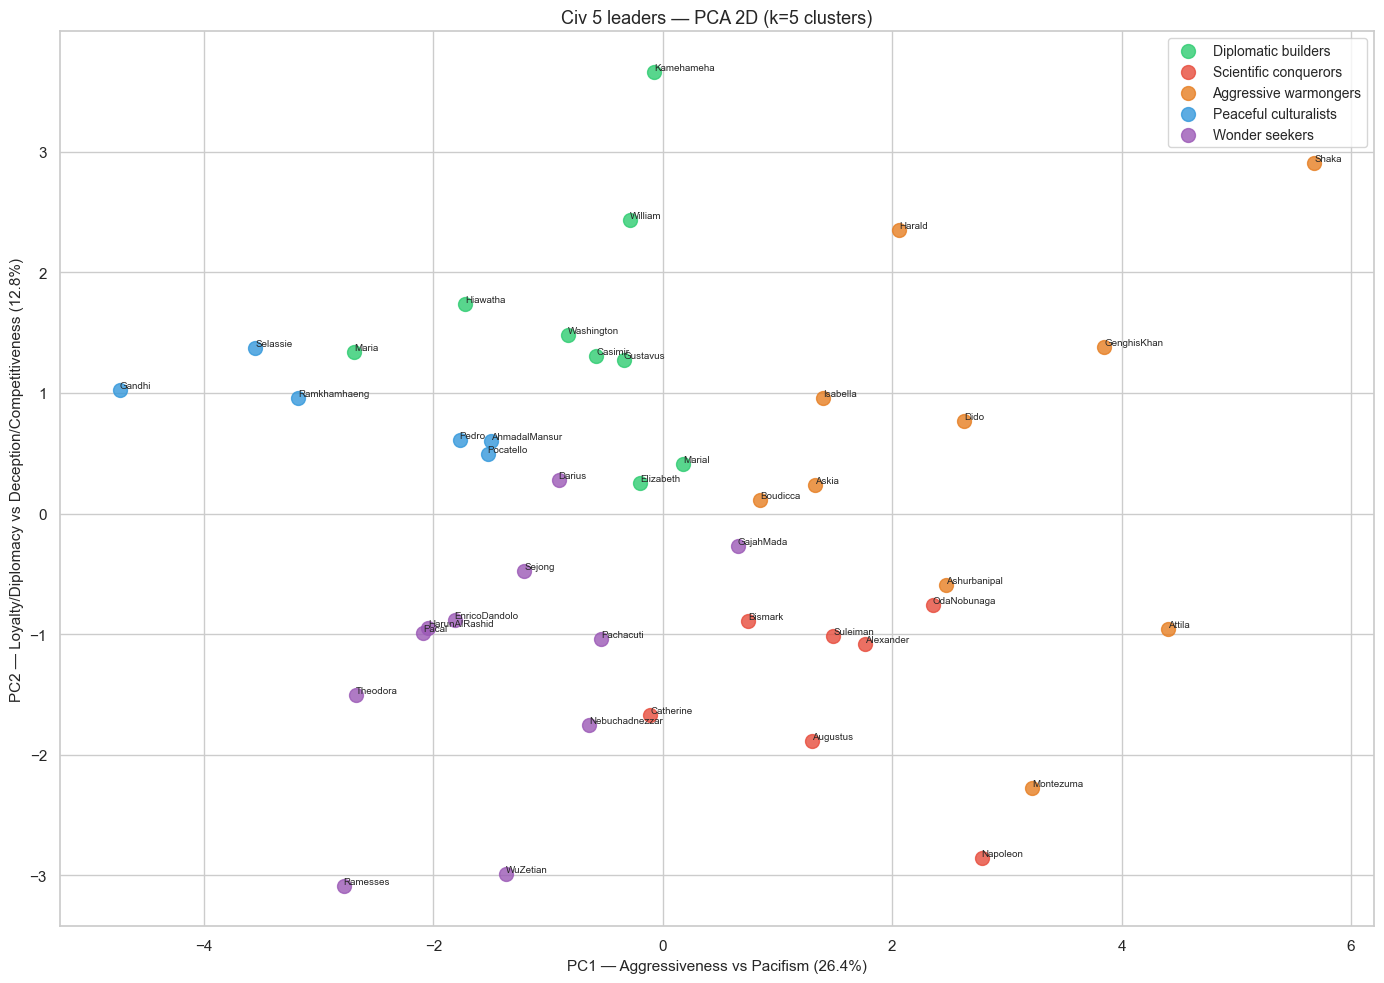

In [11]:
fig, ax = plt.subplots(figsize=(14, 10))

for cluster_id, label in CLUSTER_LABELS.items():
    mask = (features["cluster"] == cluster_id).values
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=CLUSTER_COLORS[cluster_id], label=label, s=100, alpha=0.8)
    names = features[features["cluster"] == cluster_id]["leader_name"].values
    for i, name in enumerate(names):
        ax.annotate(name, (X_pca[mask, 0][i], X_pca[mask, 1][i]),
                    fontsize=7, ha="left", va="bottom")

ax.set_xlabel(f"PC1 — Aggressiveness vs Pacifism ({pca.explained_variance_ratio_[0]:.1%})", fontsize=11)
ax.set_ylabel(f"PC2 — Loyalty/Diplomacy vs Deception/Competitiveness ({pca.explained_variance_ratio_[1]:.1%})", fontsize=11)
ax.set_title("Civ 5 leaders — PCA 2D (k=5 clusters)", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../figures/pca_2d_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

UMAP visualization

/Users/arthurperonne/Documents/Perso_Arthur/code_perso/civ5_clustering/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


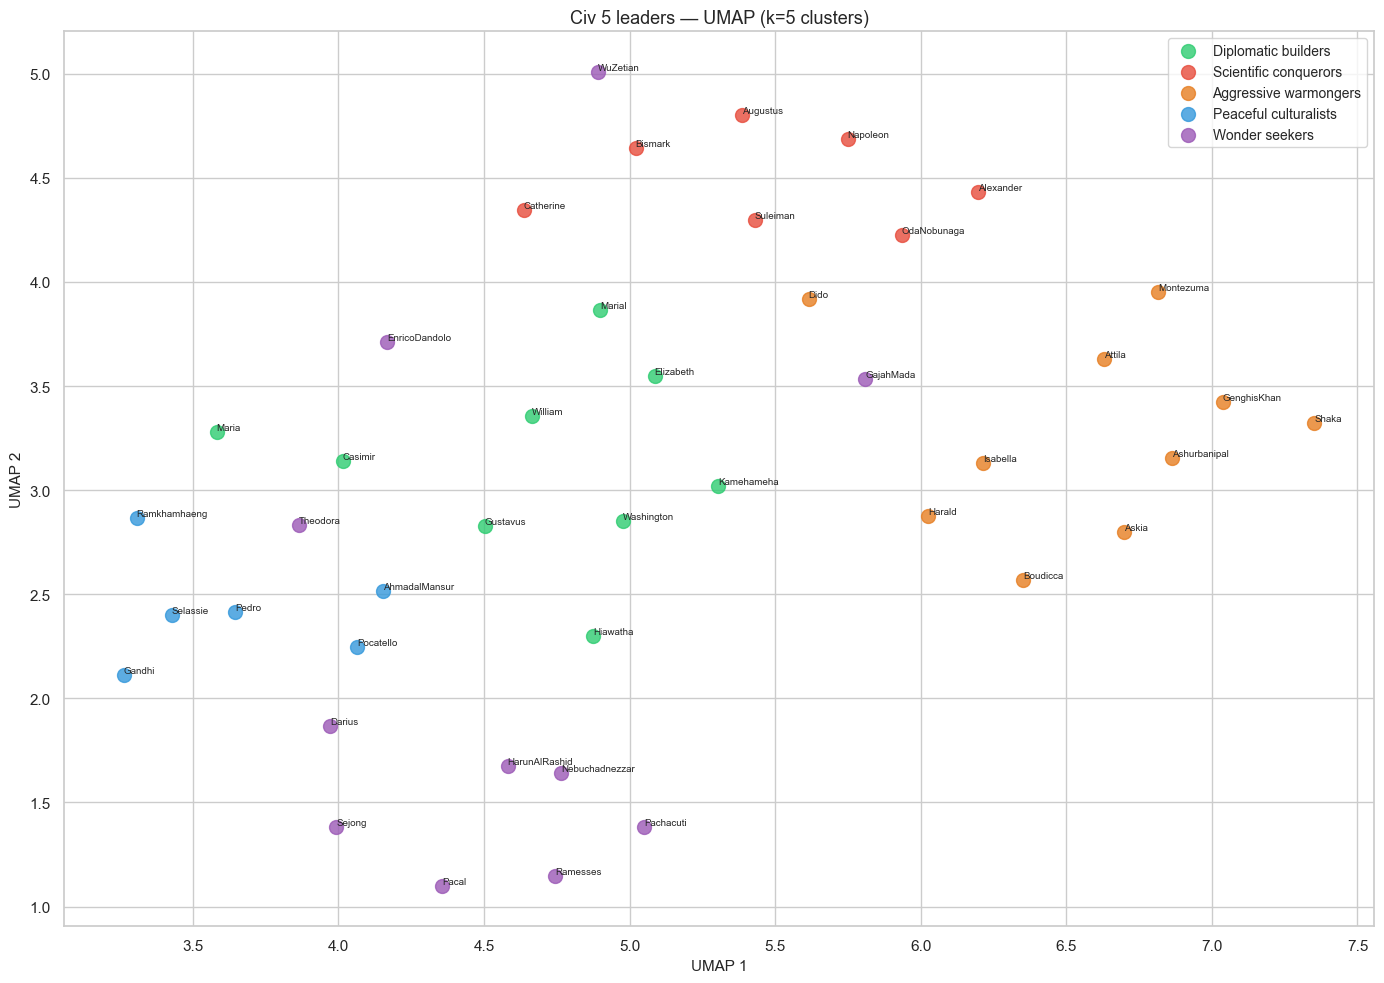

In [12]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(14, 10))

for cluster_id, label in CLUSTER_LABELS.items():
    mask = (features["cluster"] == cluster_id).values
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=CLUSTER_COLORS[cluster_id], label=label, s=100, alpha=0.8)
    names = features[features["cluster"] == cluster_id]["leader_name"].values
    for i, name in enumerate(names):
        ax.annotate(name, (X_umap[mask, 0][i], X_umap[mask, 1][i]),
                    fontsize=7, ha="left", va="bottom")

ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)
ax.set_title("Civ 5 leaders — UMAP (k=5 clusters)", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../figures/umap_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

GajahMada observation

In [13]:
comparison_gajah = pd.concat([
    features[features["leader_name"] == "GajahMada"]
        .set_index("leader_name")
        .drop(columns=["cluster"]),
    cluster_profiles.loc[[2, 4]].rename(
        index={2: "Cluster 2 (Aggressive warmongers)",
               4: "Cluster 4 (Wonder seekers)"})
], axis=0).T

print(comparison_gajah.round(2))

                         GajahMada  Cluster 2 (Aggressive warmongers)  Cluster 4 (Wonder seekers)
WarmongerHate                  5.0                               3.80                        5.09
WonderCompetitiveness          4.0                               4.30                        6.09
VictoryCompetitiveness         5.0                               6.10                        5.00
Loyalty                        4.0                               5.80                        4.82
MinorCivCompetitiveness        5.0                               4.20                        4.82
warrior                        5.4                               6.74                        4.40
friendliness                   4.0                               3.95                        5.68
deceptiveness                  6.0                               5.00                        5.64
city_state_stance             -1.0                               2.40                       -1.00
minor_ignore        

DBSCAN comparison

In [14]:
dbscan = DBSCAN(eps=4.0, min_samples=3)
labels_dbscan = dbscan.fit_predict(X_scaled)

noise_leaders = features[labels_dbscan == -1]["leader_name"].tolist()
print(f"DBSCAN outliers at eps=4.0 ({len(noise_leaders)} leaders):")
print(sorted(noise_leaders))
print("\nConclusion: DBSCAN finds no meaningful cluster structure in this dataset.")
print("K-means with k=5 is the appropriate algorithm here.")

DBSCAN outliers at eps=4.0 (20 leaders):
['Alexander', 'Ashurbanipal', 'Askia', 'Attila', 'Casimir', 'Dido', 'EnricoDandolo', 'Gandhi', 'GenghisKhan', 'Gustavus', 'Harald', 'Hiawatha', 'Maria', 'Montezuma', 'Napoleon', 'Nebuchadnezzar', 'Pocatello', 'Ramkhamhaeng', 'Shaka', 'WuZetian']

Conclusion: DBSCAN finds no meaningful cluster structure in this dataset.
K-means with k=5 is the appropriate algorithm here.
